In [1]:
# ==========================================
# STEP 1: LOAD AND EXPLORE DATA
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


In [2]:

# Load the Kaggle dataset
df = pd.read_csv('Housing.csv')

# Explore dataset structure
print("Dataset Head:")
print(df.head())
print("\nDataset Summary Statistics:")
print(df.describe())
print("\nMissing Values Count:")
print(df.isnull().sum())
print("\nDataset Columns:")
print(df.columns.tolist())


Dataset Head:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Summary Statistics:
              price          area    bedrooms   bathroom

In [3]:

# ==========================================
# STEP 2: PREPARE DATA
# ==========================================
# Handle missing values if any
df = df.dropna()

# Separate features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Convert all categorical columns into dummy/indicator variables
X = pd.get_dummies(X, drop_first=True)

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")



Training set size: 436
Test set size: 109


In [4]:

# ==========================================
# STEP 3: TRAIN LINEAR REGRESSION
# ==========================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_train_lr = lr_model.predict(X_train)
y_pred_test_lr = lr_model.predict(X_test)

# Evaluate Linear Regression
r2_train_lr = r2_score(y_train, y_pred_train_lr)
r2_test_lr = r2_score(y_test, y_pred_test_lr)
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

print("\n--- Linear Regression Results ---")
print(f"R² (Train): {r2_train_lr:.3f}")
print(f"R² (Test): {r2_test_lr:.3f}")
print(f"RMSE: Rs {rmse_test_lr:,.0f}")



--- Linear Regression Results ---
R² (Train): 0.686
R² (Test): 0.653
RMSE: Rs 1,324,507


In [5]:

# ==========================================
# STEP 4: RANDOM FOREST REGRESSOR
# ==========================================
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate Random Forest
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\n--- Random Forest Results ---")
print(f"Random Forest R²: {r2_rf:.3f}")
print(f"Random Forest RMSE: Rs {rmse_rf:,.0f}")

# Compare models
if r2_rf > r2_test_lr:
    print("\nRandom Forest is better!")
    best_model = rf_model
    best_predictions = y_pred_rf
else:
    print("\nLinear Regression is better!")
    best_model = lr_model
    best_predictions = y_pred_test_lr



--- Random Forest Results ---
Random Forest R²: 0.612
Random Forest RMSE: Rs 1,400,566

Linear Regression is better!


In [6]:

# ==========================================
# STEP 5: FEATURE IMPORTANCE & VISUALIZATION
# ==========================================
# Feature importance from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

print("\nFeature Importance Table:")
print(importance_df.sort_values('Importance', ascending=False))



Feature Importance Table:
                            Feature  Importance
0                              area    0.468430
2                         bathrooms    0.151483
9               airconditioning_yes    0.062672
4                           parking    0.057455
3                           stories    0.057133
1                          bedrooms    0.048413
12     furnishingstatus_unfurnished    0.035011
7                      basement_yes    0.030823
10                     prefarea_yes    0.030689
8               hotwaterheating_yes    0.017226
6                     guestroom_yes    0.016724
11  furnishingstatus_semi-furnished    0.013692
5                      mainroad_yes    0.010250


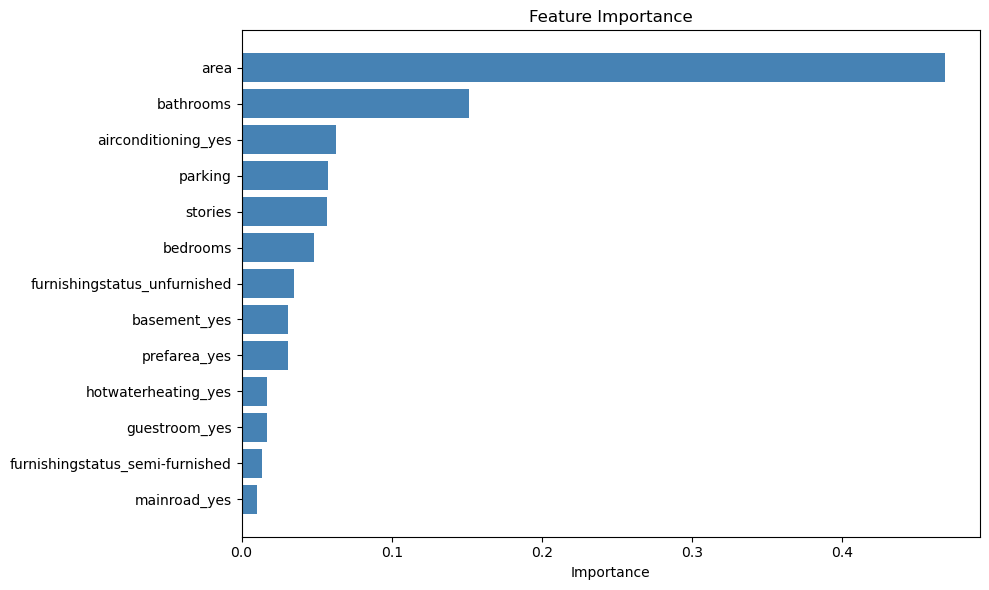

In [7]:

# Visualization 1: Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()


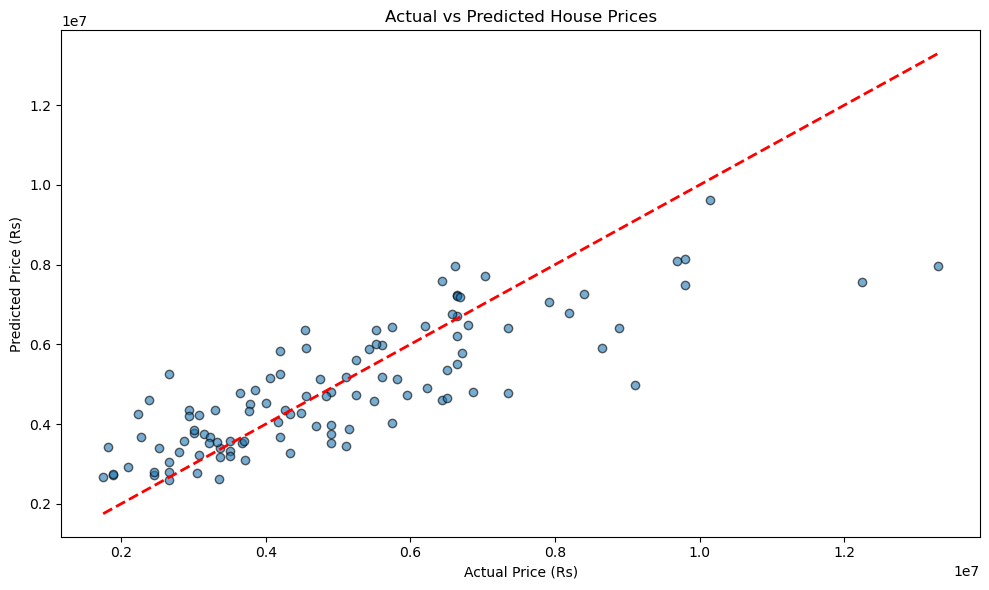

In [8]:

# Visualization 2: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, best_predictions, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (Rs)')
plt.ylabel('Predicted Price (Rs)')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.show()


In [9]:

# ==========================================
# STEP 6: MAKE PREDICTION ON NEW HOUSE DATA
# ==========================================
# Take a sample profile from the test features and modify values
new_house = X_test.iloc[[0]].copy()
new_house['area'] = 4500
new_house['bedrooms'] = 4

predicted_price = best_model.predict(new_house)
print(f"\nPredicted price for sample house: Rs {predicted_price[0]:,.0f}")


Predicted price for sample house: Rs 4,834,298


In [10]:
# ==========================================
# SAVE THE TRAINED MODEL & FEATURE COLUMNS
# ==========================================
import joblib

# Save the trained best model
joblib.dump(best_model, 'house_price_model.pkl')

# Save the exact training feature column names to ensure input alignment
joblib.dump(list(X.columns), 'model_features.pkl')

print("Saved 'house_price_model.pkl' and 'model_features.pkl' successfully!")

Saved 'house_price_model.pkl' and 'model_features.pkl' successfully!
